# Customer Churn Prediction Using Machine Learning

## Project Overview

This project develops machine learning models to predict customer churn using customer demographic, usage, support, payment, subscription, and spending information.

The objective is to preprocess the dataset, explore customer behavior, train multiple classification models, evaluate their performance, and identify the factors that are most associated with customer churn.

## Machine Learning Problem

This is a binary classification problem.

Target Variable:
- 0 → Customer does not churn
- 1 → Customer churns

Step 1 - Import libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import warnings
warnings.filterwarnings("ignore")

Step 2 - Load the dataset

In [2]:
df = pd.read_csv(
    "C:\Thiranex Internship Tasks\customer-churn-prediction\data\customer_churn_dataset-testing-master.csv"
)

df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,Female,25,14,4,27,Basic,Monthly,598,9,1
1,2,41,Female,28,28,7,13,Standard,Monthly,584,20,0
2,3,47,Male,27,10,2,29,Premium,Annual,757,21,0
3,4,35,Male,9,12,5,17,Premium,Quarterly,232,18,0
4,5,53,Female,58,24,9,2,Standard,Annual,533,18,0


Step 3 - Understand the data

In [3]:
print("Dataset Shape:", df.shape)

Dataset Shape: (64374, 12)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64374 entries, 0 to 64373
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   CustomerID         64374 non-null  int64 
 1   Age                64374 non-null  int64 
 2   Gender             64374 non-null  object
 3   Tenure             64374 non-null  int64 
 4   Usage Frequency    64374 non-null  int64 
 5   Support Calls      64374 non-null  int64 
 6   Payment Delay      64374 non-null  int64 
 7   Subscription Type  64374 non-null  object
 8   Contract Length    64374 non-null  object
 9   Total Spend        64374 non-null  int64 
 10  Last Interaction   64374 non-null  int64 
 11  Churn              64374 non-null  int64 
dtypes: int64(9), object(3)
memory usage: 5.9+ MB


In [5]:
df.describe()

,CustomerID,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Churn
count,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000,64374.000000
mean,32187.500000,41.970982,31.994827,15.080234,5.400690,17.133952,541.023379,15.498850,0.473685
std,18583.317451,13.924911,17.098234,8.816470,3.114005,8.852211,260.874809,8.638436,0.499311
min,1.000000,18.000000,1.000000,1.000000,0.000000,0.000000,100.000000,1.000000,0.000000
25%,16094.250000,30.000000,18.000000,7.000000,3.000000,10.000000,313.000000,8.000000,0.000000
50%,32187.500000,42.000000,33.000000,15.000000,6.000000,19.000000,534.000000,15.000000,0.000000
75%,48280.750000,54.000000,47.000000,23.000000,8.000000,25.000000,768.000000,23.000000,1.000000
max,64374.000000,65.000000,60.000000,30.000000,10.000000,30.000000,1000.000000,30.000000,1.000000


Step 4 - Check missing values

In [6]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": df.isnull().mean() * 100
})

missing

,Missing Values,Percentage
CustomerID,0,0.0
Age,0,0.0
Gender,0,0.0
Tenure,0,0.0
Usage Frequency,0,0.0
Support Calls,0,0.0
Payment Delay,0,0.0
Subscription Type,0,0.0
Contract Length,0,0.0
Total Spend,0,0.0


In [7]:
df.isnull().sum().sum()

0

Step 5 - Check duplicates

In [8]:
print(
    "Duplicate rows:",
    df.duplicated().sum()
)

Duplicate rows: 0


Step 6 — Check unique values

In [9]:
for column in df.columns:
    print(
        f"\n{column}:",
        df[column].nunique()
    )


CustomerID: 64374

Age: 48

Gender: 2

Tenure: 60

Usage Frequency: 30

Support Calls: 11

Payment Delay: 31

Subscription Type: 3

Contract Length: 3

Total Spend: 901

Last Interaction: 30

Churn: 2


In [10]:
print(df["Gender"].value_counts())

print(df["Subscription Type"].value_counts())

print(df["Contract Length"].value_counts())

print(df["Churn"].value_counts())

Gender
Female    34353
Male      30021
Name: count, dtype: int64
Subscription Type
Standard    21502
Basic       21451
Premium     21421
Name: count, dtype: int64
Contract Length
Monthly      22130
Annual       21410
Quarterly    20834
Name: count, dtype: int64
Churn
0    33881
1    30493
Name: count, dtype: int64


Step 7 — Analyze the target

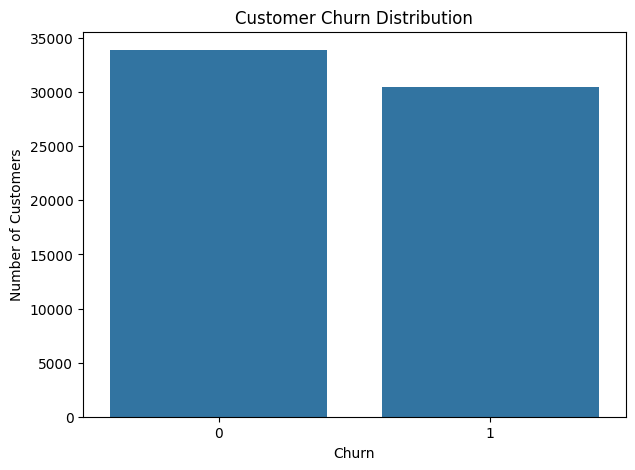

In [11]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [12]:
churn_percentage = (
    df["Churn"]
    .value_counts(normalize=True)
    * 100
)

print(churn_percentage)

Churn
0    52.631497
1    47.368503
Name: proportion, dtype: float64


Step 8 — EDA

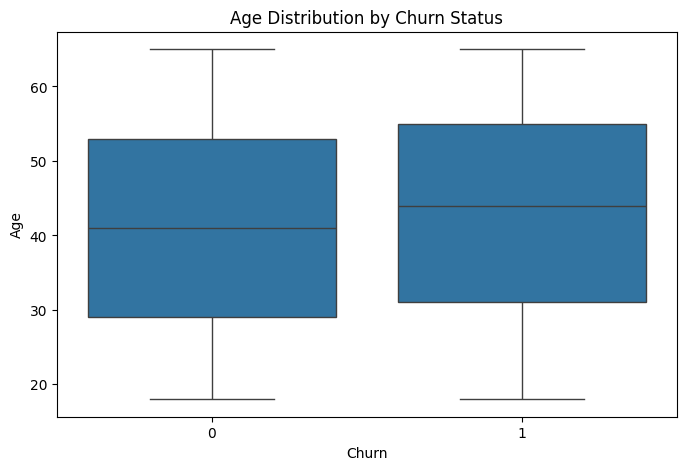

In [ ]:
#Age vs churn
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="Age"
)

plt.title("Age Distribution by Churn Status")

plt.show()

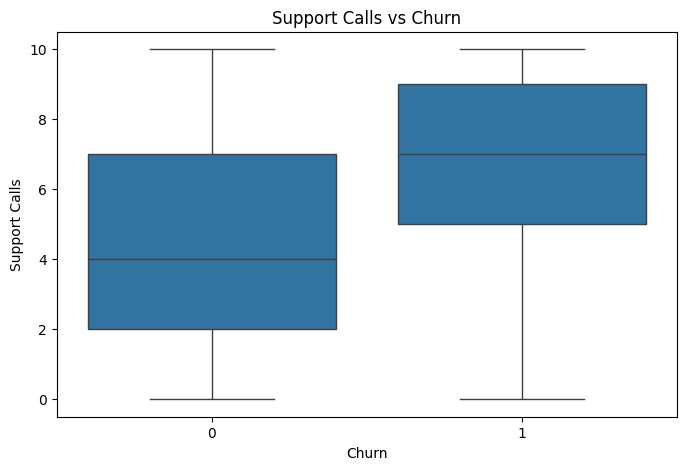

In [ ]:
#Support calls vs churn
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="Support Calls"
)

plt.title("Support Calls vs Churn")

plt.show()

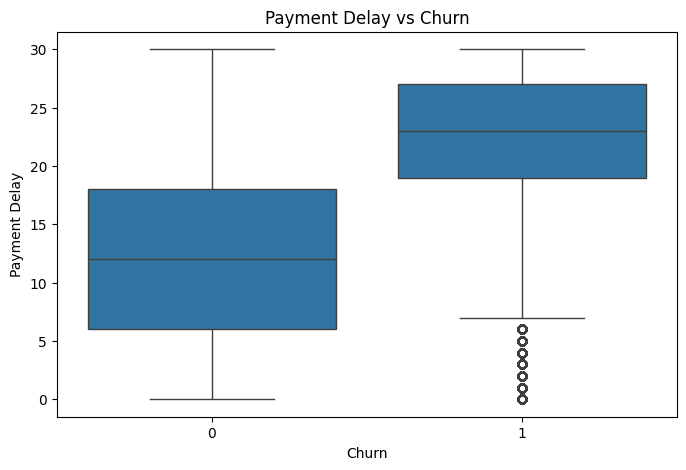

In [15]:
#Payment delay vs churn
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="Payment Delay"
)

plt.title("Payment Delay vs Churn")

plt.show()

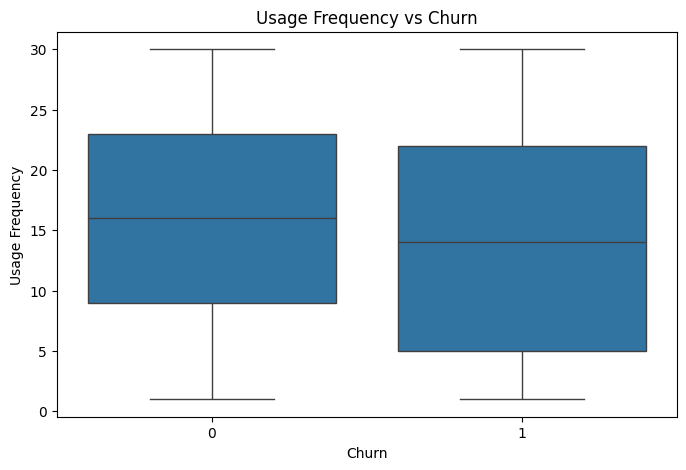

In [16]:
#Usage frequency


plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Churn",
    y="Usage Frequency"
)

plt.title("Usage Frequency vs Churn")

plt.show()

Step 9 — Categorical analysis

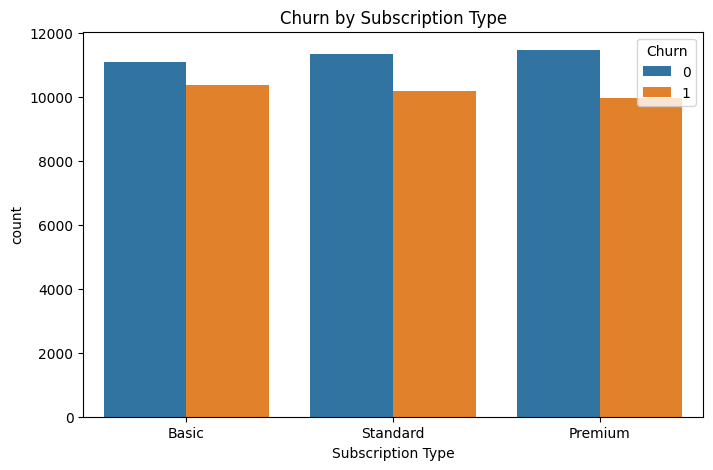

In [17]:
#Subscription type
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Subscription Type",
    hue="Churn"
)

plt.title("Churn by Subscription Type")

plt.show()

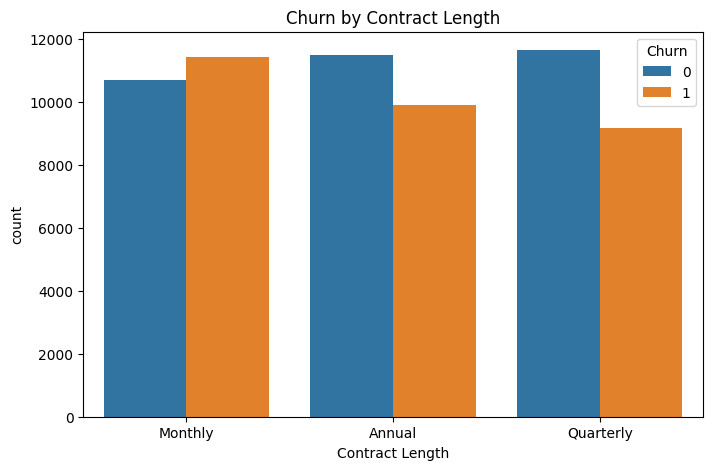

In [18]:
#Contract length
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Contract Length",
    hue="Churn"
)

plt.title("Churn by Contract Length")

plt.show()

Step 10 — Important decision: CustomerID

We should not use CustomerID as a machine-learning feature.

Why?

CustomerID is simply an identifier.

It doesn't represent customer behavior.

So.

In [19]:
X = df.drop(
    ["Churn", "CustomerID"],
    axis=1
)

y = df["Churn"]

Step 11 — Encode categorical variables

In [20]:
X = pd.get_dummies(
    X,
    drop_first=True
)

In [22]:
X.head()

,Age,Tenure,Usage Frequency,Support Calls,Payment Delay,Total Spend,Last Interaction,Gender_Male,Subscription Type_Premium,Subscription Type_Standard,Contract Length_Monthly,Contract Length_Quarterly
0,22,25,14,4,27,598,9,False,False,False,True,False
1,41,28,28,7,13,584,20,False,False,True,True,False
2,47,27,10,2,29,757,21,True,True,False,False,False
3,35,9,12,5,17,232,18,True,True,False,False,True
4,53,58,24,9,2,533,18,False,False,True,False,False


Step 12 — Train/test split

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

Step 13 — Scale features

In [24]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

Step 14 — Logistic Regression

In [25]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

logistic_pred = logistic_model.predict(
    X_test_scaled
)

Step 15 — Decision Tree

In [26]:
tree_model = DecisionTreeClassifier(
    max_depth=6,
    random_state=42
)

tree_model.fit(
    X_train,
    y_train
)

tree_pred = tree_model.predict(
    X_test
)

Step 16 — Random Forest

In [27]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)

Step 17 — Compare models

In [28]:
def evaluate_model(name, y_true, predictions):

    return {
        "Model": name,
        "Accuracy": accuracy_score(
            y_true,
            predictions
        ),
        "Precision": precision_score(
            y_true,
            predictions
        ),
        "Recall": recall_score(
            y_true,
            predictions
        ),
        "F1 Score": f1_score(
            y_true,
            predictions
        )
    }

In [29]:
results = pd.DataFrame([
    evaluate_model(
        "Logistic Regression",
        y_test,
        logistic_pred
    ),

    evaluate_model(
        "Decision Tree",
        y_test,
        tree_pred
    ),

    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred
    )
])

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.827107,0.813603,0.823742,0.818641
1,Decision Tree,0.979184,0.968053,0.988687,0.978261
2,Random Forest,0.998136,0.999014,0.997049,0.998031


Step 18 — Model comparison visualization

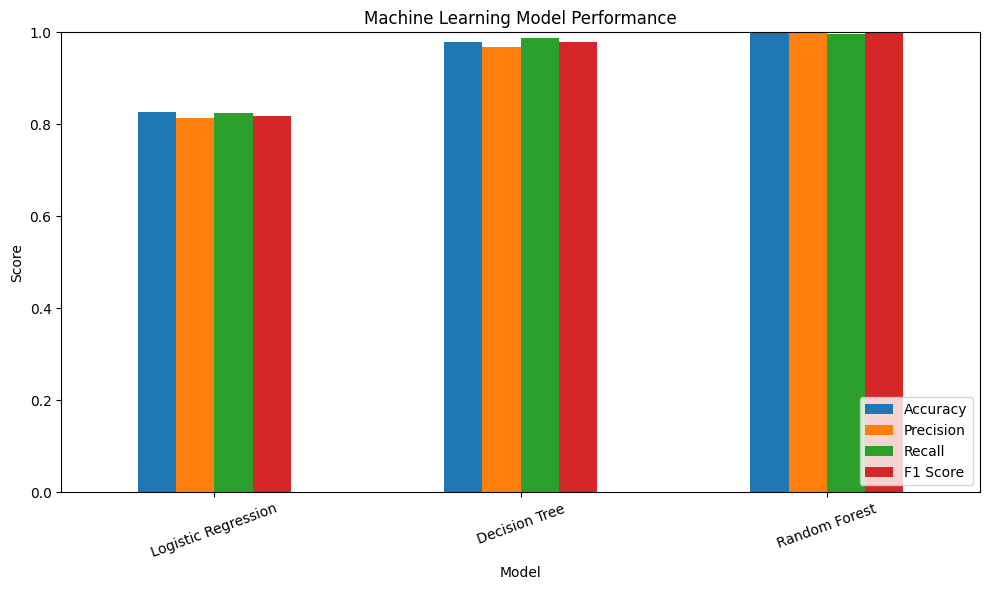

In [30]:
results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Machine Learning Model Performance")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=20)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

Step 19 — Confusion Matrix

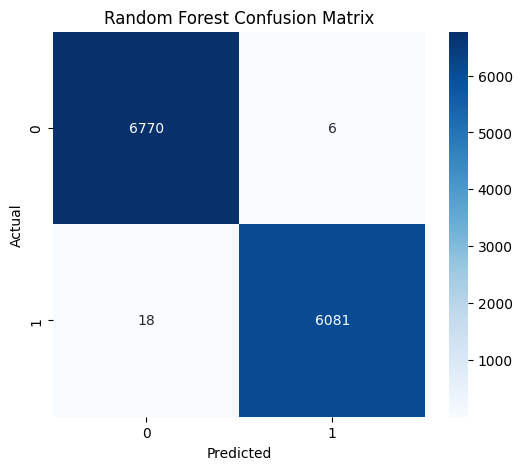

In [31]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Step 20 — ROC Curve

In [32]:
rf_probability = rf_model.predict_proba(
    X_test
)[:, 1]

fpr, tpr, thresholds = roc_curve(
    y_test,
    rf_probability
)

auc_score = roc_auc_score(
    y_test,
    rf_probability
)

print("ROC-AUC:", auc_score)

ROC-AUC: 0.9999886756359502


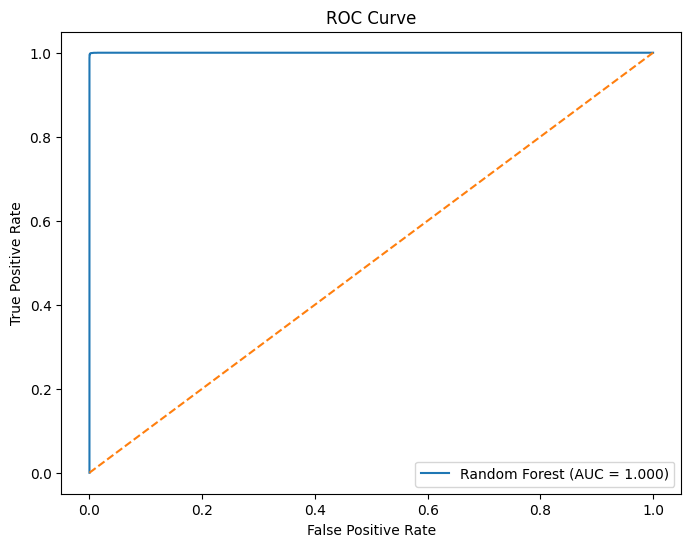

In [33]:
plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

Step 21 — Feature importance

In [34]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

In [36]:
# Top 10 features
top_features = feature_importance.head(10)

top_features

,Feature,Importance
4,Payment Delay,0.444717
3,Support Calls,0.163500
1,Tenure,0.102799
2,Usage Frequency,0.080960
7,Gender_Male,0.073298
5,Total Spend,0.047130
0,Age,0.041765
10,Contract Length_Monthly,0.025525
6,Last Interaction,0.009657
11,Contract Length_Quarterly,0.007026


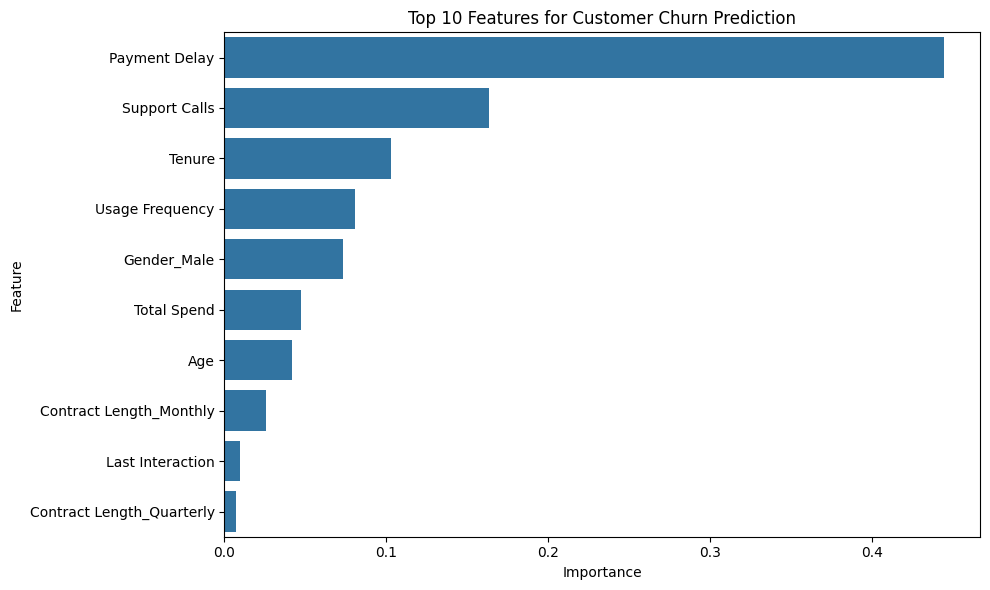

In [37]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Features for Customer Churn Prediction"
)

plt.tight_layout()
plt.show()

In [ ]:
------------------------------------------------------------------------------

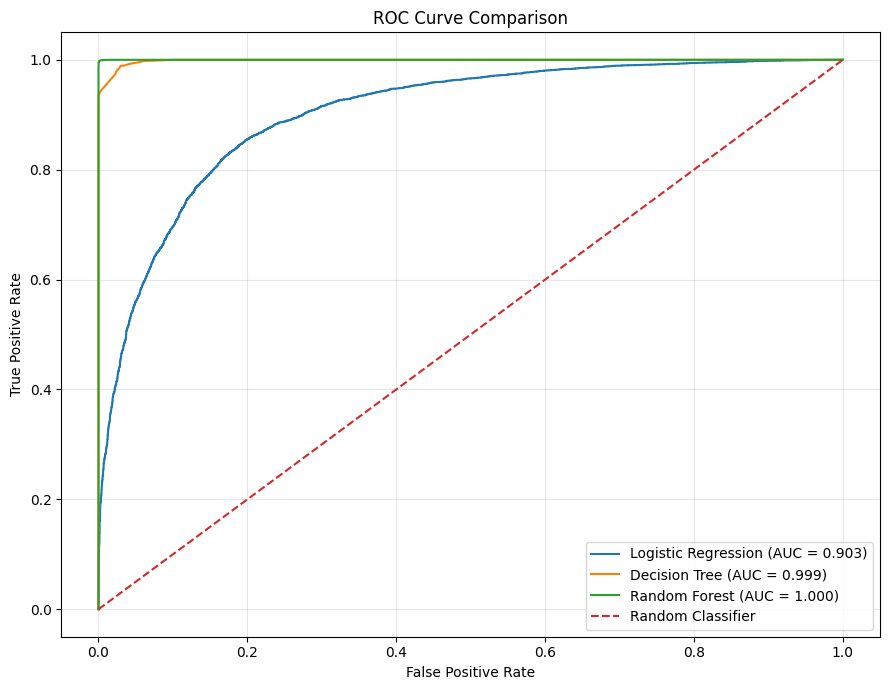

Logistic Regression AUC: 0.9030
Decision Tree AUC: 0.9986
Random Forest AUC: 1.0000
